# 250. Count Univalue Subtrees
https://leetcode.com/problems/count-univalue-subtrees/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| **Post-order DFS** | **O(n)** | **O(h)** | **Check each subtree bottom-up** |

## Methodology

A univalue subtree is one where all nodes have the same value. We use **post-order DFS**: for each node, recursively check if left and right subtrees are univalue and if their values match the current node. A leaf is always univalue. We maintain a global counter incremented whenever a subtree qualifies.

## Solutions

### C#

In [ ]:
// 250. Count Univalue Subtrees
// Time: O(n) | Space: O(h)
public class TreeNode {
    public int val;
    public TreeNode left;
    public TreeNode right;
    public TreeNode(int val = 0) { this.val = val; }
}

public class Solution {
    private int count = 0;
    
    public int CountUnivalSubtrees(TreeNode root) {
        count = 0;
        IsUni(root);
        return count;
    }
    
    private bool IsUni(TreeNode node) {
        if (node == null) return true;
        
        bool left = IsUni(node.left);
        bool right = IsUni(node.right);
        
        if (left && right) {
            if (node.left != null && node.left.val != node.val) return false;
            if (node.right != null && node.right.val != node.val) return false;
            count++;
            return true;
        }
        return false;
    }
}

### Python

In [ ]:
# 250. Count Univalue Subtrees
# Time: O(n) | Space: O(h)
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def countUnivalSubtrees(self, root: TreeNode) -> int:
        self.count = 0
        
        def is_uni(node):
            if not node:
                return True
            left = is_uni(node.left)
            right = is_uni(node.right)
            if left and right:
                if node.left and node.left.val != node.val:
                    return False
                if node.right and node.right.val != node.val:
                    return False
                self.count += 1
                return True
            return False
        
        is_uni(root)
        return self.count

### Go

In [ ]:
// 250. Count Univalue Subtrees
// Time: O(n) | Space: O(h)
type TreeNode struct {
    Val   int
    Left  *TreeNode
    Right *TreeNode
}

func countUnivalSubtrees(root *TreeNode) int {
    count := 0
    var isUni func(*TreeNode) bool
    isUni = func(node *TreeNode) bool {
        if node == nil {
            return true
        }
        left := isUni(node.Left)
        right := isUni(node.Right)
        if left && right {
            if node.Left != nil && node.Left.Val != node.Val {
                return false
            }
            if node.Right != nil && node.Right.Val != node.Val {
                return false
            }
            count++
            return true
        }
        return false
    }
    isUni(root)
    return count
}

### Rust

In [ ]:
// 250. Count Univalue Subtrees
// Time: O(n) | Space: O(h)
use std::rc::Rc;
use std::cell::RefCell;

#[derive(Debug, PartialEq, Eq)]
pub struct TreeNode {
    pub val: i32,
    pub left: Option<Rc<RefCell<TreeNode>>>,
    pub right: Option<Rc<RefCell<TreeNode>>>,
}

impl Solution {
    pub fn count_unival_subtrees(root: Option<Rc<RefCell<TreeNode>>>) -> i32 {
        let mut count = 0;
        Self::is_uni(&root, &mut count);
        count
    }
    
    fn is_uni(node: &Option<Rc<RefCell<TreeNode>>>, count: &mut i32) -> bool {
        match node {
            None => true,
            Some(n) => {
                let n = n.borrow();
                let left = Self::is_uni(&n.left, count);
                let right = Self::is_uni(&n.right, count);
                if left && right {
                    if let Some(l) = &n.left {
                        if l.borrow().val != n.val { return false; }
                    }
                    if let Some(r) = &n.right {
                        if r.borrow().val != n.val { return false; }
                    }
                    *count += 1;
                    true
                } else {
                    false
                }
            }
        }
    }
}

## Example Scenarios

1. **Common Case** — Balanced tree with mixed values  
   **Input:** `root = [5, 1, 5, 5, 5, null, 5]`  
   Leaves 5, 5, 5 are univalue (3). Left subtree rooted at 1 has children both 5 but 1 ≠ 5, so not univalue. Right subtree [5, null, 5] is univalue (1). Root 5 has left child 1 ≠ 5, not univalue. Answer = $4$.

2. **Slightly Complex** — All nodes have the same value  
   **Input:** `root = [5, 5, 5, 5, 5, null, 5]`  
   Every subtree is univalue because all values are 5. With 6 nodes total, every node roots a univalue subtree. Answer = $6$.

3. **Edge Case: Time Factor** — Skewed tree (linked list shape)  
   **Input:** `root = [1, 2, null, 3, null, 4, null, ..., n]` with $n$ nodes, all distinct  
   The recursion visits every node exactly once: $O(n)$ time. Only the deepest leaf is univalue. Every other node has a child with a different value. Answer = $1$. The tree height equals $n$, maximizing recursion stack depth.

4. **Edge Case: Space Factor** — Deep recursion on a right-skewed tree  
   **Input:** A tree of depth $h = 5000$ where every node has only a right child, all with value 1  
   All $5000$ subtrees are univalue (answer = $5000$), but the recursion stack grows to depth $5000$. Each stack frame holds the node reference and boolean return value, consuming $O(h)$ space.

5. **Almost-Impossible but Plausible** — Single node with extreme value  
   **Input:** `root = [-2147483648]` (one node with value $-2^{31}$)  
   A single leaf is always a univalue subtree. No children to compare. The extreme value tests that the solution handles `INT_MIN` without overflow. Answer = $1$.


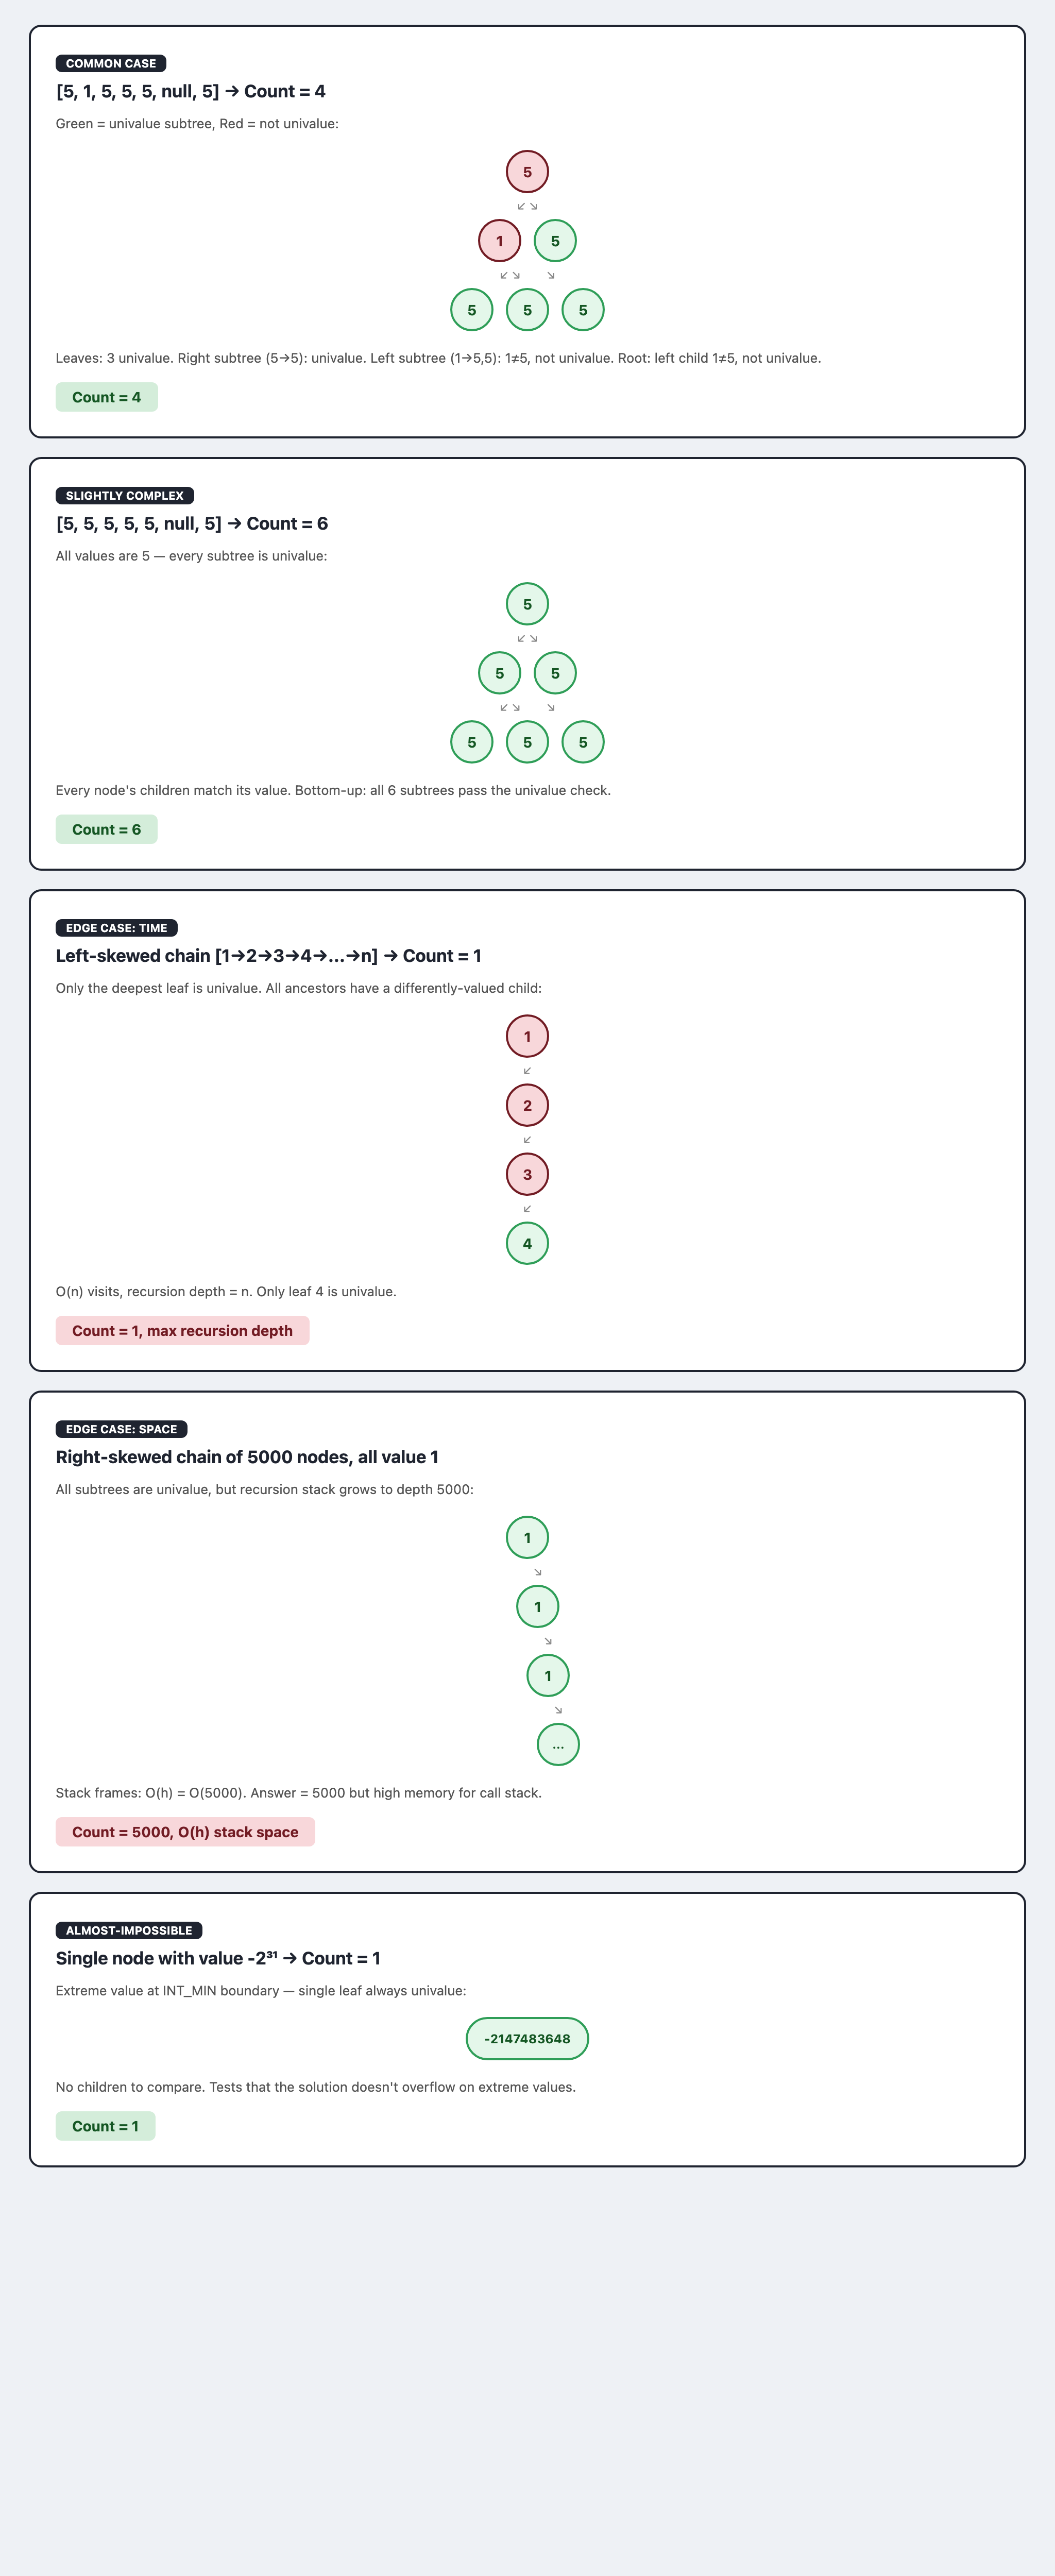